# LOST - Continuous Mountain Car

In [1]:
import numpy as np
import gymnasium as gym
import random 

In [2]:
# Cambiar render_mode a rgb_array para entrenar/testear sino human
env_id = 'MountainCarContinuous-v0'
env = gym.make(env_id, render_mode='rgb_array')

In [3]:
from q_learning_agent import QLearningAgent

Observation Space

In [4]:
env.observation_space

Box([-1.2  -0.07], [0.6  0.07], (2,), float32)

Action Space

In [5]:
env.action_space

Box(-1.0, 1.0, (1,), float32)

Discretización de los estados

In [6]:
x_space = np.linspace(-1.2, 0.6, 100)
vel_space = np.linspace(-0.07, 0.07, 100)
x_space

array([-1.2       , -1.18181818, -1.16363636, -1.14545455, -1.12727273,
       -1.10909091, -1.09090909, -1.07272727, -1.05454545, -1.03636364,
       -1.01818182, -1.        , -0.98181818, -0.96363636, -0.94545455,
       -0.92727273, -0.90909091, -0.89090909, -0.87272727, -0.85454545,
       -0.83636364, -0.81818182, -0.8       , -0.78181818, -0.76363636,
       -0.74545455, -0.72727273, -0.70909091, -0.69090909, -0.67272727,
       -0.65454545, -0.63636364, -0.61818182, -0.6       , -0.58181818,
       -0.56363636, -0.54545455, -0.52727273, -0.50909091, -0.49090909,
       -0.47272727, -0.45454545, -0.43636364, -0.41818182, -0.4       ,
       -0.38181818, -0.36363636, -0.34545455, -0.32727273, -0.30909091,
       -0.29090909, -0.27272727, -0.25454545, -0.23636364, -0.21818182,
       -0.2       , -0.18181818, -0.16363636, -0.14545455, -0.12727273,
       -0.10909091, -0.09090909, -0.07272727, -0.05454545, -0.03636364,
       -0.01818182,  0.        ,  0.01818182,  0.03636364,  0.05

Obtener el estado a partir de la observación

In [7]:
def get_state(obs):
    x, vel = obs
    x_bin = np.digitize(x, x_space)
    vel_bin = np.digitize(vel, vel_space)
    return x_bin, vel_bin

In [8]:
state = get_state(np.array([-0.4, 0.02]))
state

(np.int64(45), np.int64(64))

Discretización de las acciones

In [9]:
actions = list(np.linspace(-1, 1, 10))
actions

[np.float64(-1.0),
 np.float64(-0.7777777777777778),
 np.float64(-0.5555555555555556),
 np.float64(-0.33333333333333337),
 np.float64(-0.11111111111111116),
 np.float64(0.11111111111111116),
 np.float64(0.33333333333333326),
 np.float64(0.5555555555555554),
 np.float64(0.7777777777777777),
 np.float64(1.0)]

In [10]:
def get_sample_action():
    return random.choice(actions)

Inicilización de la tabla Q

In [11]:
Q = np.zeros((len(x_space) + 1, len(vel_space) + 1, len(actions)))
Q

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

Obtención de la acción a partir de la tabla Q

In [12]:
def optimal_policy(state, Q):
    action = actions[np.argmax(Q[state])]
    return action

Epsilon-Greedy Policy

In [13]:
def epsilon_greedy_policy(state, Q, epsilon=0.1):
    explore = np.random.binomial(1, epsilon)
    if explore:
        action = get_sample_action()
    else:
        action = optimal_policy(state, Q)
        
    return action

# Prueba q quedó

In [ ]:
# Testear el agente entrenado (sin exploración)
print("\nTesteando agente entrenado...")
from dyna_q_agent import DynaQAgent
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)
agent.load_model('dyna_agent_trained.npy')

env = gym.make('MountainCarContinuous-v0', render_mode='human')
test_rewards, test_steps = agent.test_agent(env, episodes=3, render=True)
env.close()

print(f"\nPromedio de rewards en testing: {np.mean(test_rewards):.2f}")
print(f"Promedio de steps en testing: {np.mean(test_steps):.2f}")

# Q-Learning Agent

In [15]:
from q_learning_agent import QLearningAgent

In [16]:
from q_experiments_manager import ExperimentManager

# 1. Crear el entorno
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')

# 2. Inicializar el mánager de experimentos
manager = ExperimentManager()

In [ ]:
print("Entrenando agente Q-Learning...")
id_1 = "8k_episodes_eps015"
manager.train_run(
    env=env, 
    run_id=id_1,
    x_bins=100,         
    vel_bins=100,       
    action_bins=20,    
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.15,
    max_steps=3000
)
env.close()

# Visualizar progreso de entrenamient0
manager.plot_training_history(id_1)

# DynaQAgent

In [ ]:
from dyna_q_agent import DynaQAgent

In [ ]:
# Crear agente con configuración inicial
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)

# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Dyna-Q...")
agent.train_agent(
    env, 
    episodes=5000,
    alpha=0.03,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.2,
    max_steps=1000,
    planning_steps=20
)
env.close()

# Guardar el modelo entrenado
agent.save_model('dyna_agent_trained.npy')

# Visualizar progreso de entrenamiento
agent.plot_training_history()

In [ ]:
# Cargar un modelo Dyna-Q guardado y evaluarlo
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)
agent.load_model('dyna_agent_trained.npy')

env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Evaluando el modelo cargado...")
test_rewards, test_steps, success_count = agent.test_agent(env, episodes=5, render=False)
env.close()

print(f"\nExitos en testing: {success_count}/5")
print(f"Promedio de rewards: {np.mean(test_rewards):.2f}")
print(f"Promedio de steps: {np.mean(test_steps):.2f}")

# Q-Learning variando el epsilon

In [ ]:
from q_learning_agent import QLearningAgent

# Crear agente con configuración inicial
agent = QLearningAgent(x_bins=100, vel_bins=100, action_bins=20)
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')

In [ ]:
print("Entrenando agente Q-Learning...")
id_e1 = "8k_episodes_eps075"
manager.train_run(
    env, 
    run_id=id_e1,
    x_bins=100,
    vel_bins=100,
    action_bins=20,
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.075,
    max_steps=3000,
)
env.close()
manager.plot_training_history(id_e1)

In [ ]:
# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
id_e2 = "8k_episodes_eps025"
manager.train_run(
    env, 
    run_id=id_e2,
    x_bins=100,
    vel_bins=100,
    action_bins=20,
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.025,
    max_steps=3000,
)
env.close()
manager.plot_training_history(id_e2)

In [ ]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
id_e3 = "8k_episodes_eps001"
manager.train_run(
    env, 
    run_id=id_e3,
    x_bins=100,
    vel_bins=100,    
    action_bins=20,
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.001,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_e3)

In [ ]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
id_e4 = "5500_episodes_eps0005"
manager.train_run(
    env, 
    run_id=id_e4,
    x_bins=100,
    vel_bins=100,
    action_bins=20,
    episodes=5500,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.0005,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_e4)

Variando el epsilon start

In [ ]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
id_es1= "8k_episodes_eps075"
manager.train_run(
    env, 
    run_id=id_es1,
    x_bins=100,
    vel_bins=100,
    action_bins=20,
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.75, 
    epsilon_end=0.025,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_es1)

Comparacion de graficas

In [ ]:
manager.plot_comparisons()

# Analsis para mejorar dicretización

## Q-learning

### Setup

In [14]:
import gymnasium as gym
from q_experiments_manager import ExperimentManager
from q_learning_agent import QLearningAgent
from discretization_evaluator import DiscretizationEvaluator

env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
manager = ExperimentManager()

In [ ]:
evaluator = DiscretizationEvaluator(manager)

train_kwargs = {
    'episodes': 5000,
    'alpha': 0.05,
    'gamma': 0.99,
    'epsilon_start': 0.99,
    'epsilon_end': 0.0005,
    'max_steps': 3000,
}

### Pruebas variando los action Bins

In [ ]:
evaluator.evaluate_group(
    env=env,
    x_bins_list=[50],
    vel_bins_list=[50],
    action_bins_list=[5, 10, 20],  
    train_kwargs=train_kwargs,
    test_episodes=10,
    test_max_steps=3000,
    prefix="G1_Acciones"
)

In [ ]:
evaluator.plot_ranking()

### Variaciones con mejor resultado anterior

In [ ]:
evaluator.evaluate_group(
    env=env,
    x_bins_list=[30, 100],      # <--- Baja y alta resolución de posición
    vel_bins_list=[20, 100],     # <--- Baja y alta resolución de velocidad
    action_bins_list=[10],       # Fijamos el ganador tentativo del grupo anterior
    train_kwargs=train_kwargs,
    test_episodes=10,
    test_max_steps=3000,
    prefix="G2_Estados"
)

env.close()

In [ ]:
print("\n*** PROCESANDO RESULTADOS DE LOS GRUPOS EJECUTADOS ***")
evaluator.print_summary()

## Gráficas

In [ ]:
evaluator.plot_heatmap(metric='avg_reward')
evaluator.plot_pareto(metric='avg_reward')
evaluator.plot_convergence(top_n=3)

# Con los valores resultantes

30, 20 y 10

Entrenando agente Q-Learning...

[4k_episodes_eps015] Iniciando experimento con Q-Table de tamaño: (31, 21, 10)
[4k_episodes_eps015] Ep 800/4000 - Avg Reward: -94.61, Steps: 3000
[4k_episodes_eps015] Ep 1600/4000 - Avg Reward: -64.33, Steps: 2111
[4k_episodes_eps015] Ep 2400/4000 - Avg Reward: 28.20, Steps: 426
[4k_episodes_eps015] Ep 3200/4000 - Avg Reward: 84.59, Steps: 379
[4k_episodes_eps015] Ep 4000/4000 - Avg Reward: 91.73, Steps: 149
--> Experimento '4k_episodes_eps015' guardado con éxito en el historial.


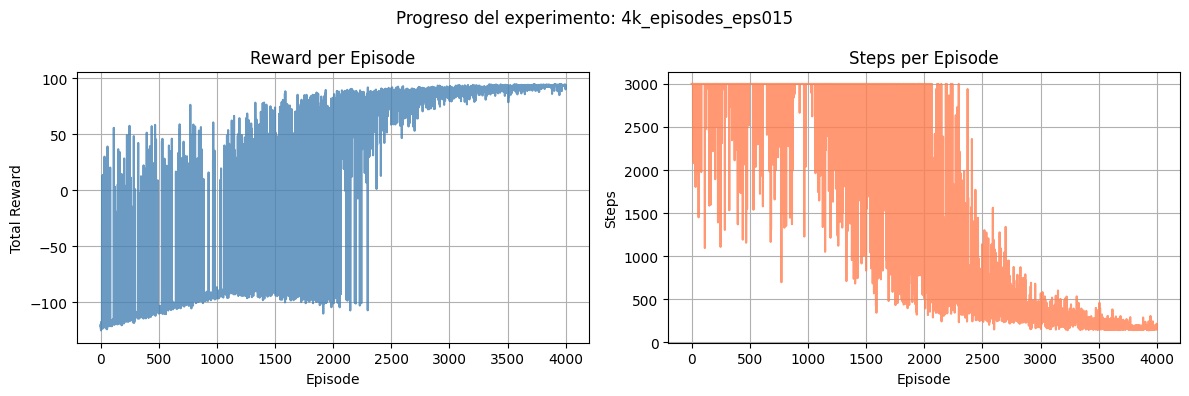

In [17]:
print("Entrenando agente Q-Learning...")
id_a1 = "4k_episodes_eps015"
manager.train_run(
    env=env, 
    run_id=id_a1,
    x_bins=30,         
    vel_bins=20,       
    action_bins=10,    
    episodes=4000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.0005,
    max_steps=3000
)
env.close()

# Visualizar progreso de entrenamient0
manager.plot_training_history(id_a1)

# Anterior Ver si sacar

In [ ]:
from q_learning_agent import QLearningAgent

# Crear agente con configuración inicial
agent = QLearningAgent(x_bins=100, vel_bins=100, action_bins=20)

# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
agent.train_agent(
    env, 
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.15,
    max_steps=3000
)
env.close()

# Visualizar progreso de entrenamiento
agent.plot_training_history()

# Mostrar tasa de éxito en entrenamiento
#train_successes = sum(agent.training_history['successes'])
#print(f"\nÉxitos en entrenamiento: {train_successes}/{len(agent.training_history['successes'])} ({train_successes / len(agent.training_history['successes']) * 100:.1f}%)")

In [ ]:
from dyna_q_agent import DynaQAgent

# Crear agente con configuración inicial
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)

# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Dyna-Q...")
agent.train_agent(
    env, 
    episodes=5000,
    alpha=0.03,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.2,
    max_steps=1000,
    planning_steps=20
)
env.close()

# Guardar el modelo entrenado
agent.save_model('dyna_agent_trained.npy')

# Visualizar progreso de entrenamiento
agent.plot_training_history()

In [ ]:
# Continuar entrenamiento a partir del modelo guardado
from dyna_q_agent import DynaQAgent

print("\nContinuando entrenamiento desde el modelo guardado...")
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)
agent.load_model('dyna_agent_trained.npy')

env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
agent.train_agent(
    env,
    episodes=1500,
    alpha=0.03,
    gamma=0.98,
    epsilon_start=0.1,
    epsilon_end=0.05,
    max_steps=500,
    planning_steps=35
)
env.close()

agent.save_model('dyna_agent_trained_v2.npy')
agent.plot_training_history()
print("Modelo actualizado guardado en dyna_agent_trained_v2.npy")

In [ ]:
# Diagnóstico rápido del modelo cargado
import numpy as np

from q_learning_agent import QLearningAgent

# Crear agente con configuración inicial
agent = QLearningAgent(x_bins=100, vel_bins=100, action_bins=20)
agent.load_model('dyna_agent_trained.npy')

print('Q shape:', getattr(agent, 'Q', None).shape if hasattr(agent, 'Q') else 'no Q')
print('Q sum:', np.sum(agent.Q))
print('Q max:', np.max(agent.Q))
print('Non-zero count:', np.count_nonzero(agent.Q))

# Mostrar los valores de Q para el estado inicial
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
obs, _ = env.reset()
state = agent.discretize_state(obs)
print('Initial observation:', obs)
print('Discretized state:', state)
print('Q[state]:', agent.Q[state])

# Acción determinista según la política actual
action = agent.next_action(state, epsilon=0.0, training=False)
print('Selected action (deterministic):', action)
env.close()